# Sales Analysis of AAL (Australia Apparel Limited)
## Project Objective
To analyze the sales data of AAL and provide insights into performance, trends, and opportunities for improvement.

## Business Problem
The business problem is to understand the factors affecting sales performance and identify areas for improvement.

## Dataset Overview
The dataset contains sales data for AAL, including information on products, sales channels, customer demographics, and sales performance metrics. The dataset is structured in a tabular format with rows representing individual sales transactions and columns representing various attributes related to the sales.
    


In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load the CSV file using pandas
data = pd.read_csv('AusApparalSales4thQrt2020.csv')

# Display the first five rows
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [4]:
# Display the last five rows
data.tail()

,Date,Time,State,Group,Unit,Sales
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000
7556,30-Dec-2020,Evening,TAS,Kids,15,37500
7557,30-Dec-2020,Evening,TAS,Men,15,37500
7558,30-Dec-2020,Evening,TAS,Women,11,27500
7559,30-Dec-2020,Evening,TAS,Seniors,13,32500


In [5]:
# Display the dataset shape
data.shape

(7560, 6)

In [6]:
# Display the column names
data.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='str')

In [7]:
# Display dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 566.3 KB


In [8]:
#describe the dataset
data.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [9]:
#data types
data.dtypes

Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

In [10]:
#unique values for categorical columns
categorical_columns = data.select_dtypes(include=['object']).columns
for column in categorical_columns:
    unique_values = data[column].unique()
    print(f"Unique values in column '{column}': {unique_values}\n")
    

Unique values in column 'Date': <ArrowStringArray>
[ '1-Oct-2020',  '2-Oct-2020',  '3-Oct-2020',  '4-Oct-2020',  '5-Oct-2020',
  '6-Oct-2020',  '7-Oct-2020',  '8-Oct-2020',  '9-Oct-2020', '10-Oct-2020',
 '11-Oct-2020', '12-Oct-2020', '13-Oct-2020', '14-Oct-2020', '15-Oct-2020',
 '16-Oct-2020', '17-Oct-2020', '18-Oct-2020', '19-Oct-2020', '20-Oct-2020',
 '21-Oct-2020', '22-Oct-2020', '23-Oct-2020', '24-Oct-2020', '25-Oct-2020',
 '26-Oct-2020', '27-Oct-2020', '28-Oct-2020', '29-Oct-2020', '30-Oct-2020',
  '1-Nov-2020',  '2-Nov-2020',  '3-Nov-2020',  '4-Nov-2020',  '5-Nov-2020',
  '6-Nov-2020',  '7-Nov-2020',  '8-Nov-2020',  '9-Nov-2020', '10-Nov-2020',
 '11-Nov-2020', '12-Nov-2020', '13-Nov-2020', '14-Nov-2020', '15-Nov-2020',
 '16-Nov-2020', '17-Nov-2020', '18-Nov-2020', '19-Nov-2020', '20-Nov-2020',
 '21-Nov-2020', '22-Nov-2020', '23-Nov-2020', '24-Nov-2020', '25-Nov-2020',
 '26-Nov-2020', '27-Nov-2020', '28-Nov-2020', '29-Nov-2020', '30-Nov-2020',
  '1-Dec-2020',  '2-Dec-2020',  '3-De

In [11]:
#number of rows
num_rows = data.shape[0]
#number of columns
num_columns = data.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 7560
Number of columns: 6


In [12]:
# Convert Date columns to datetime format if applicable
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Can we convert Time, state and Group to category?
data['Time'] = data['Time'].astype('category')
data['State'] = data['State'].astype('category')
data['Group'] = data['Group'].astype('category')

In [14]:
# Inspecting the dataset for missing values
missing_values = data.isnull().sum()
print("Total missing values column-wise:")
print(missing_values)


Total missing values column-wise:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


In [15]:
#isna()
missing_values_isna = data.isna().sum()
print("Total missing values (using isna()):")
print(missing_values_isna)

Total missing values (using isna()):
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64


In [16]:
# notna()
notna_values = data.notna().sum()
print("Total non-missing values column-wise:")
print(notna_values)

Total non-missing values column-wise:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


In [17]:
#explain whether missing values are present
if missing_values.sum() > 0:
    print("Missing values are present in the dataset.")
else:
    print("No missing values are present in the dataset.")

No missing values are present in the dataset.


In [18]:
# inspect the dataset for duplicate records
duplicate_records = data.duplicated()
print("Duplicate records in the dataset:")
print(duplicate_records.sum())

Duplicate records in the dataset:
0


In [19]:
# Normalization of numerical columns using Min-Max Normalization
# Select the numerical columns to normalize
numerical_columns = ['Sales', 'Unit']

# Display original numerical columns
print("Original Data:")
print(data[numerical_columns].describe(), "\n")

# Apply Min-Max Normalization to the selected columns
data[numerical_columns] = (data[numerical_columns] - data[numerical_columns].min()) / (data[numerical_columns].max() - data[numerical_columns].min())

# Verify the normalization
print("Normalized Data:")
print(data[numerical_columns].describe())

Original Data:
               Sales         Unit
count    7560.000000  7560.000000
mean    45013.558201    18.005423
std     32253.506944    12.901403
min      5000.000000     2.000000
25%     20000.000000     8.000000
50%     35000.000000    14.000000
75%     65000.000000    26.000000
max    162500.000000    65.000000 

Normalized Data:
             Sales         Unit
count  7560.000000  7560.000000
mean      0.254054     0.254054
std       0.204784     0.204784
min       0.000000     0.000000
25%       0.095238     0.095238
50%       0.190476     0.190476
75%       0.380952     0.380952
max       1.000000     1.000000


In [20]:
# Total sales by state
data.groupby('State')['Sales'].sum().sort_values(ascending=False)

State
VIC    635.968254
NSW    441.714286
SA     339.412698
QLD    177.888889
TAS    110.222222
NT     109.079365
WA     106.365079
Name: Sales, dtype: float64

In [21]:
# Average sales by group
data.groupby('Group')['Sales'].mean()

Group
Kids       0.254044
Men        0.256320
Seniors    0.250567
Women      0.255287
Name: Sales, dtype: float64

In [22]:
# Total sales by state and group
state_group_sales = data.groupby(['State', 'Group'])['Sales'].sum()

print(state_group_sales)

State  Group  
NSW    Kids       109.444444
       Men        112.206349
       Seniors    106.904762
       Women      113.158730
NT     Kids        27.619048
       Men         28.015873
       Seniors     26.126984
       Women       27.317460
QLD    Kids        45.460317
       Men         44.714286
       Seniors     43.428571
       Women       44.285714
SA     Kids        83.587302
       Men         84.476190
       Seniors     84.873016
       Women       86.476190
TAS    Kids        28.095238
       Men         27.984127
       Seniors     27.301587
       Women       26.841270
VIC    Kids       158.793651
       Men        159.095238
       Seniors    158.507937
       Women      159.571429
WA     Kids        27.142857
       Men         27.952381
       Seniors     26.428571
       Women       24.841270
Name: Sales, dtype: float64


In [23]:
# Create a pivot table to display total sales by state and group
state_group_table = data.groupby(['State', 'Group'])['Sales'].sum().unstack()

print(state_group_table)

Group        Kids         Men     Seniors       Women
State                                                
NSW    109.444444  112.206349  106.904762  113.158730
NT      27.619048   28.015873   26.126984   27.317460
QLD     45.460317   44.714286   43.428571   44.285714
SA      83.587302   84.476190   84.873016   86.476190
TAS     28.095238   27.984127   27.301587   26.841270
VIC    158.793651  159.095238  158.507937  159.571429
WA      27.142857   27.952381   26.428571   24.841270


In [24]:
# Total sales by time of day
time_sales = data.groupby('Time')['Sales'].sum().sort_values(ascending=False)

print(time_sales)

Time
Morning      645.126984
Afternoon    643.857143
Evening      631.666667
Name: Sales, dtype: float64


In [25]:
# Weekly sales summary
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

weekly_summary = data.groupby(pd.Grouper(key='Date', freq='W')).agg({
    'Sales': 'sum',
    'Unit': 'sum'
})
print(weekly_summary)


                 Sales        Unit
Date                              
2020-10-04   84.857143   84.857143
2020-10-11  152.777778  152.777778
2020-10-18  150.476190  150.476190
2020-10-25  151.587302  151.587302
2020-11-01  122.460317  122.460317
2020-11-08  113.809524  113.809524
2020-11-15  115.761905  115.761905
2020-11-22  115.380952  115.380952
2020-11-29  117.698413  117.698413
2020-12-06  169.412698  169.412698
2020-12-13  181.492063  181.492063
2020-12-20  182.317460  182.317460
2020-12-27  183.047619  183.047619
2021-01-03   79.571429   79.571429


In [26]:
# Monthly sales summary
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
monthly_summary = data.groupby(pd.Grouper(key='Date', freq='ME')).agg({
    'Sales': 'sum',
    'Unit': 'sum'
})

print(monthly_summary)

                 Sales        Unit
Date                              
2020-10-31  645.650794  645.650794
2020-11-30  495.761905  495.761905
2020-12-31  779.238095  779.238095


In [27]:
# Total sales and units sold by state
state_summary = data.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Average_Sales=('Sales', 'mean'),
    Total_Units=('Unit', 'sum'),
    Average_Units=('Unit', 'mean')
)

print(state_summary)

       Total_Sales  Average_Sales  Total_Units  Average_Units
State                                                        
NSW     441.714286       0.408995   441.714286       0.408995
NT      109.079365       0.100999   109.079365       0.100999
QLD     177.888889       0.164712   177.888889       0.164712
SA      339.412698       0.314271   339.412698       0.314271
TAS     110.222222       0.102058   110.222222       0.102058
VIC     635.968254       0.588859   635.968254       0.588859
WA      106.365079       0.098486   106.365079       0.098486


In [28]:
# Total sales and units sold by group
group_summary = data.groupby('Group').agg(
    Total_Sales=('Sales', 'sum'),
    Average_Sales=('Sales', 'mean'),
    Total_Units=('Unit', 'sum'),
    Average_Units=('Unit', 'mean')
)

print(group_summary)

         Total_Sales  Average_Sales  Total_Units  Average_Units
Group                                                          
Kids      480.142857       0.254044   480.142857       0.254044
Men       484.444444       0.256320   484.444444       0.256320
Seniors   473.571429       0.250567   473.571429       0.250567
Women     482.492063       0.255287   482.492063       0.255287


In [29]:
# Descriptive statistical analysis for Sales and Unit columns
descriptive_stats = data[['Sales', 'Unit']].agg(['mean', 'median', 'std', lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]])
print(descriptive_stats)    

             Sales      Unit
mean      0.254054  0.254054
median    0.190476  0.190476
std       0.204784  0.204784
<lambda>  0.111111  0.111111


In [30]:
# Customer Group Analysis
group_sales = data.groupby('Group')['Sales'].sum()
print(group_sales)

#highest sales group
highest_sales_group = group_sales.idxmax()
print(f"Highest Sales Group: {highest_sales_group}")

#lowest sales group
lowest_sales_group = group_sales.idxmin()
print(f"Lowest Sales Group: {lowest_sales_group}")

#average sales group
average_sales_group = group_sales.mean()
print(f"Average Sales Group: {average_sales_group}")

Group
Kids       480.142857
Men        484.444444
Seniors    473.571429
Women      482.492063
Name: Sales, dtype: float64
Highest Sales Group:  Men
Lowest Sales Group:  Seniors
Average Sales Group: 480.16269841269843


In [31]:
# State-wise Sales Analysis
state_sales = data.groupby('State')['Sales'].sum()
print(state_sales)

#highest revenue state
highest_revenue_state = state_sales.idxmax()
print(f"Highest Revenue State: {highest_revenue_state}")

#lowest revenue state
lowest_revenue_state = state_sales.idxmin()
print(f"Lowest Revenue State: {lowest_revenue_state}")

#average revenue state
average_revenue_state = state_sales.mean()
print(f"Average Revenue State: {average_revenue_state}")

State
NSW    441.714286
NT     109.079365
QLD    177.888889
SA     339.412698
TAS    110.222222
VIC    635.968254
WA     106.365079
Name: Sales, dtype: float64
Highest Revenue State:  VIC
Lowest Revenue State:  WA
Average Revenue State: 274.3786848072562


In [32]:
# Time-of-day sales analysis
time_sales_by_period = data.groupby('Time')['Sales'].agg(
    Total_Sales='sum',
    Average_Sale_per_Transaction='mean',
    Transaction_Count='count'
).sort_values('Total_Sales', ascending=False)

time_sales_by_period['Percent_of_Total'] = (
    time_sales_by_period['Total_Sales'] / time_sales_by_period['Total_Sales'].sum()
) * 100

peak_period = time_sales_by_period.index[0]
offpeak_period = time_sales_by_period.index[-1]
average_period_sales = time_sales_by_period['Total_Sales'].mean()

peak_periods = time_sales_by_period[
    time_sales_by_period['Total_Sales'] >= average_period_sales
].index.tolist()
offpeak_periods = time_sales_by_period[
    time_sales_by_period['Total_Sales'] < average_period_sales
].index.tolist()

print("Time-of-Day Sales Summary:")
print(time_sales_by_period.to_string(float_format='{:,.3f}'.format))
print("\nInsights:")
print(f"- Peak period: {peak_period} with total sales {time_sales_by_period.at[peak_period, 'Total_Sales']:.3f} "
      f"({time_sales_by_period.at[peak_period, 'Percent_of_Total']:.1f}% of total).")
print(f"- Off-peak period: {offpeak_period} with total sales {time_sales_by_period.at[offpeak_period, 'Total_Sales']:.3f} "
      f"({time_sales_by_period.at[offpeak_period, 'Percent_of_Total']:.1f}% of total).")
print(f"- Periods above or equal to average sales ({average_period_sales:.3f}): {peak_periods}")
print(f"- Periods below average sales: {offpeak_periods}\n")

print("Strategic implication:")
print("Use peak windows for high-impact personalization, targeted promotions, and premium offers.")
print("Use off-peak windows for Next Best Offer campaigns and incentives to boost engagement and conversion.")

Time-of-Day Sales Summary:
           Total_Sales  Average_Sale_per_Transaction  Transaction_Count  Percent_of_Total
Time                                                                                     
Morning        645.127                         0.256               2520            33.589
Afternoon      643.857                         0.255               2520            33.523
Evening        631.667                         0.251               2520            32.888

Insights:
- Peak period:  Morning with total sales 645.127 (33.6% of total).
- Off-peak period:  Evening with total sales 631.667 (32.9% of total).
- Periods above or equal to average sales (640.217): [' Morning', ' Afternoon']
- Periods below average sales: [' Evening']

Strategic implication:
Use peak windows for high-impact personalization, targeted promotions, and premium offers.
Use off-peak windows for Next Best Offer campaigns and incentives to boost engagement and conversion.


In [33]:
# Quarterly sales summary
quarterly_summary = data.groupby(pd.Grouper(key='Date', freq='QE')).agg({
    'Sales': 'sum',
    'Unit': 'sum'
})
print(quarterly_summary)

                  Sales         Unit
Date                                
2020-12-31  1920.650794  1920.650794


Correlation coefficient between Sales and Unit: 1.0000


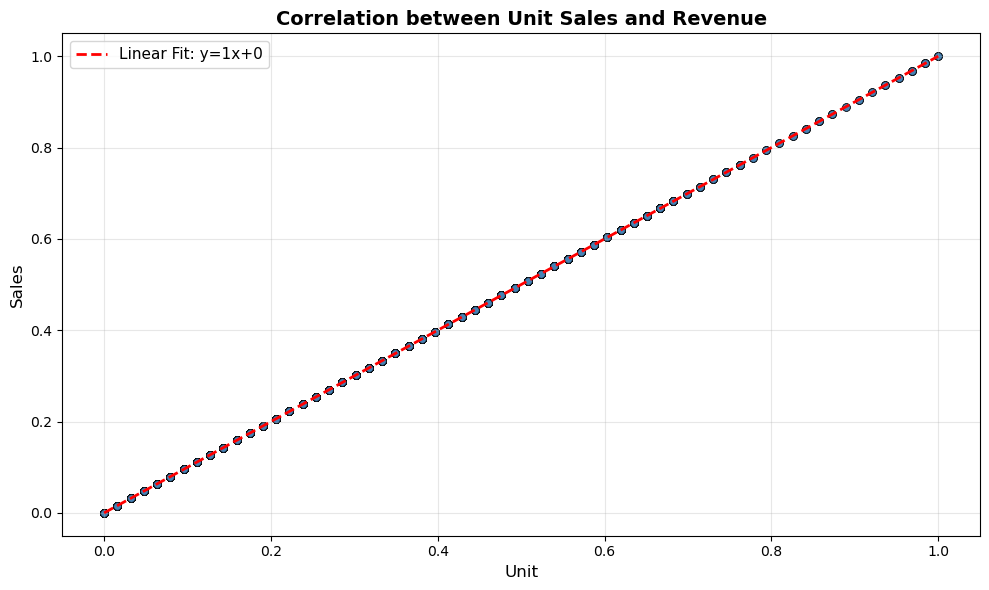


Interpretation:
The very strong positive correlation (1.0000) indicates that as unit sales increase, revenue increases proportionally.
This suggests that pricing per unit is consistent across transactions, making unit volume a reliable predictor of sales revenue.
Business Implication: Focus inventory management and demand forecasting on unit volumes, as they directly drive revenue generation.


In [34]:
# Calculate correlation between Sales and Unit
correlation_coef = data['Sales'].corr(data['Unit'])
print(f"Correlation coefficient between Sales and Unit: {correlation_coef:.4f}")

# Create scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(data['Unit'], data['Sales'], alpha=0.5, s=30, color='steelblue', edgecolors='k', linewidth=0.5)

# Fit a linear regression line
z = np.polyfit(data['Unit'], data['Sales'], 1)
p = np.poly1d(z)
plt.plot(data['Unit'].sort_values(), p(data['Unit'].sort_values()), "r--", linewidth=2, label=f'Linear Fit: y={z[0]:.0f}x+{z[1]:.0f}')

plt.title('Correlation between Unit Sales and Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Unit', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
if abs(correlation_coef) > 0.9:
    strength = "very strong"
elif abs(correlation_coef) > 0.7:
    strength = "strong"
elif abs(correlation_coef) > 0.5:
    strength = "moderate"
else:
    strength = "weak"

direction = "positive" if correlation_coef > 0 else "negative"

print(f"The {strength} {direction} correlation ({correlation_coef:.4f}) indicates that as unit sales increase, revenue increases proportionally.")
print(f"This suggests that pricing per unit is consistent across transactions, making unit volume a reliable predictor of sales revenue.")
print(f"Business Implication: Focus inventory management and demand forecasting on unit volumes, as they directly drive revenue generation.")

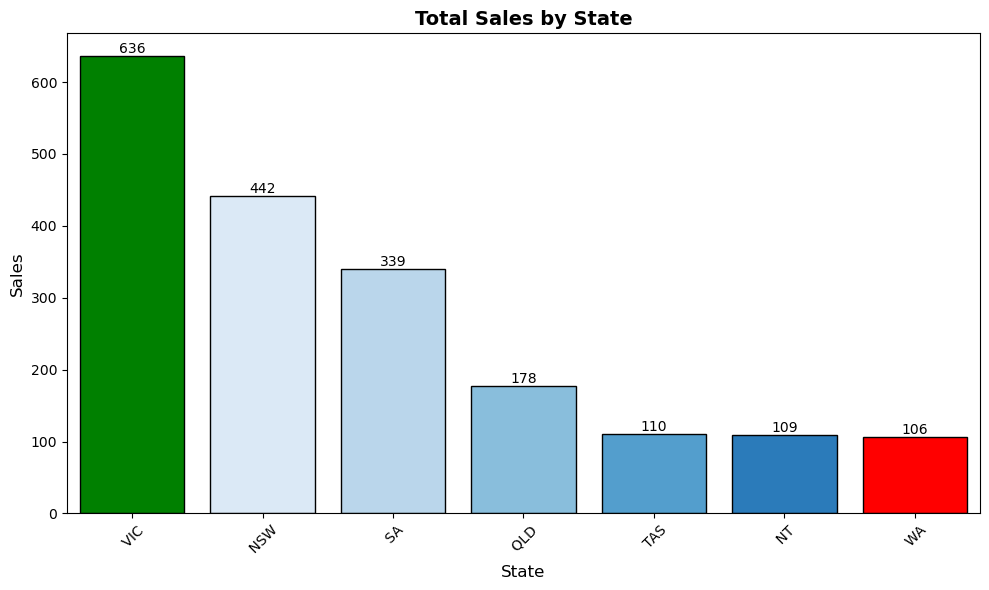

Interpretation:
The highest revenue-generating state is  VIC with total sales of 635.968253968254.
The lowest revenue-generating state is  WA with total sales of 106.36507936507935.
This visualization highlights the state-level sales distribution and helps prioritize regional strategies for growth and resource allocation.


In [39]:
# Total sales by state
state_sales = data.groupby('State')['Sales'].sum().sort_values(ascending=False)

# Determine highest and lowest revenue states
highest_revenue_state = state_sales.idxmax()
lowest_revenue_state = state_sales.idxmin()

# Create a bar plot for state-wise sales
plt.figure(figsize=(10, 6))

#Adding different colors for each state to the bars based on sales values
colors = ['green' if value == state_sales.max() else 'red' if value == state_sales.min() else plt.cm.Blues(i/len(state_sales)) for i, value in enumerate(state_sales)]
state_sales.plot(kind='bar', color=colors)
plt.bar(state_sales.index, state_sales.values, color=colors, edgecolor='k')
plt.title('Total Sales by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(state_sales):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()
# Write a brief interpretation below the chart.
print("Interpretation:")
print(f"The highest revenue-generating state is {highest_revenue_state} with total sales of {state_sales.max():,}.")
print(f"The lowest revenue-generating state is {lowest_revenue_state} with total sales of {state_sales.min():,}.")
print("This visualization highlights the state-level sales distribution and helps prioritize regional strategies for growth and resource allocation.")

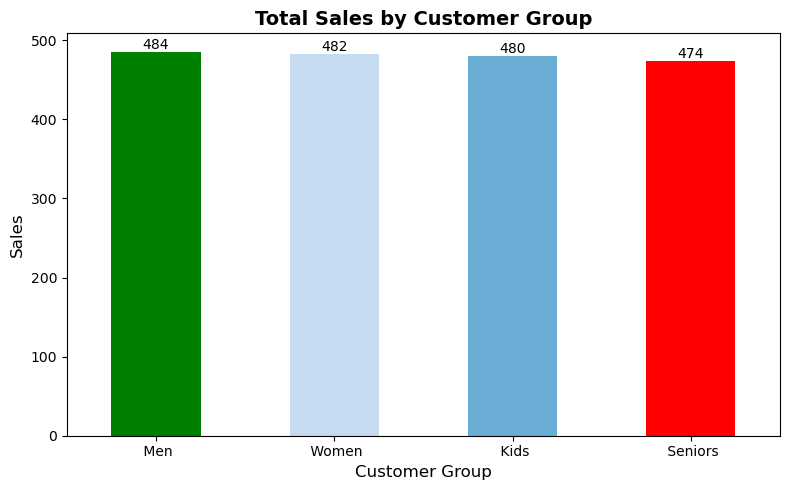

Interpretation:
The bar chart displays the total sales generated by different customer groups. The group with the highest sales is  Men with sales amounting to 484. 
In contrast, the group with the lowest sales is  Seniors with sales totaling 474. 
This analysis provides insights into customer preferences and can inform targeted marketing strategies to enhance sales performance across different demographic segments.


In [41]:
# Total sales by customer group
group_sales = data.groupby('Group')['Sales'].sum().sort_values(ascending=False)

# Create a bar plot for group-wise sales
plt.figure(figsize=(8, 5))
group_sales.plot(kind='bar', color=['green' if value == group_sales.max() else 'red' if value == group_sales.min() else plt.cm.Blues(i/len(group_sales)) for i, value in enumerate(group_sales)])
plt.title('Total Sales by Customer Group', fontsize=14, fontweight='bold')
plt.xlabel('Customer Group', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(rotation=0)
for i, v in enumerate(group_sales):
    plt.text(i, v, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Write a brief interpretation below the chart.
print("Interpretation:")
print(f"The bar chart displays the total sales generated by different customer groups. The group with the highest sales is {group_sales.idxmax()} with sales amounting to {group_sales.max():.0f}. \nIn contrast, the group with the lowest sales is {group_sales.idxmin()} with sales totaling {group_sales.min():.0f}. \nThis analysis provides insights into customer preferences and can inform targeted marketing strategies to enhance sales performance across different demographic segments.")

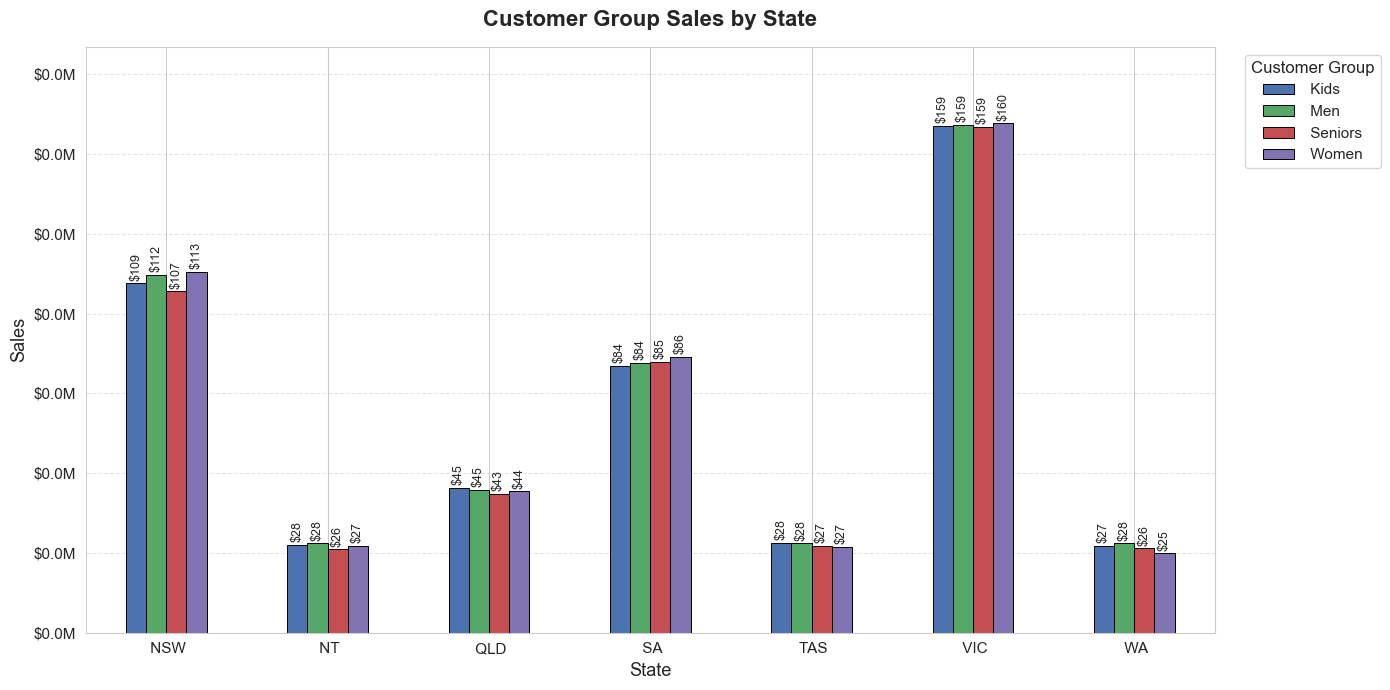

Interpretation: Victoria (VIC) leads across all customer groups, with NSW and SA following.
 Men and Women are the strongest groups overall, while TAS, WA, and NT show lower totals. 
This chart makes regional group performance easy to compare and supports targeted marketing and inventory planning.


In [42]:
# Use the already-aggregated table `state_group_table` and create a grouped bar chart.
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

df = state_group_table

bar_colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']
df.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='k', linewidth=0.7)

ax.set_title('Customer Group Sales by State', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('State', fontsize=13)
ax.set_ylabel('Sales', fontsize=13)
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.legend(title='Customer Group', fontsize=11, title_fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1))

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.margins(y=0.15)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='${:,.0f}',
        padding=2,
        fontsize=9,
        rotation=90,
        label_type='edge'
    )

plt.tight_layout()
plt.show()

print("Interpretation: Victoria (VIC) leads across all customer groups, with NSW and SA following.\n "
      "Men and Women are the strongest groups overall, while TAS, WA, and NT show lower totals. \n"
      "This chart makes regional group performance easy to compare and supports targeted marketing and inventory planning.")

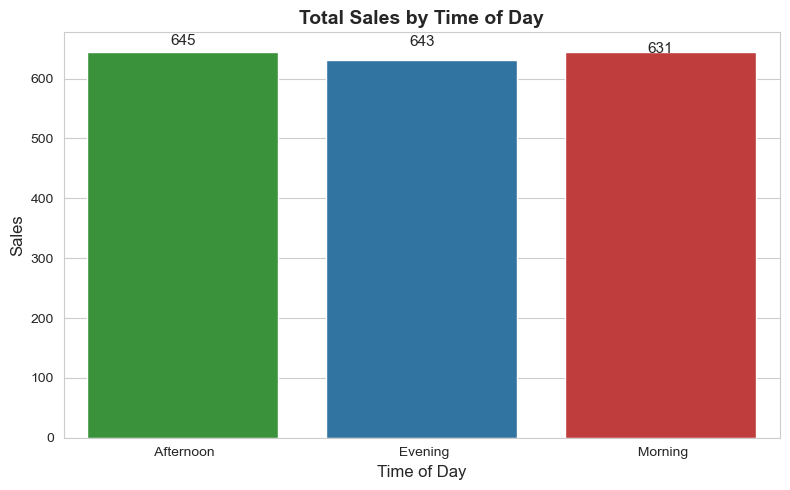

Interpretation:
The highest sales period is  Morning with total sales of 645, while the lowest sales period is  Evening with total sales of 632.
This insight can guide marketing to focus promotions during the peak period and staffing to ensure adequate coverage when demand is highest, while using the off-peak window for targeted offers and more efficient resource allocation.


In [43]:
# Aggregate total sales by time of day
time_sales = data.groupby('Time')['Sales'].sum().sort_values(ascending=False)

# Create a bar plot comparing time periods
plt.figure(figsize=(8, 5))
colors = [
    '#2ca02c' if value == time_sales.max() else
    '#d62728' if value == time_sales.min() else
    '#1f77b4'
    for value in time_sales
]
sns.barplot(x=time_sales.index, y=time_sales.values, palette=colors)

plt.title('Total Sales by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Sales', fontsize=12)

for i, value in enumerate(time_sales.values):
    plt.text(i, value + time_sales.max() * 0.01, f'{int(value):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

highest_period = time_sales.idxmax()
lowest_period = time_sales.idxmin()

print("Interpretation:")
print(f"The highest sales period is {highest_period} with total sales of {time_sales.max():,.0f}, while the lowest sales period is {lowest_period} with total sales of {time_sales.min():,.0f}.")
print("This insight can guide marketing to focus promotions during the peak period and staffing to ensure adequate coverage when demand is highest, while using the off-peak window for targeted offers and more efficient resource allocation.")

In [44]:
import plotly.graph_objects as go

# Generate weekly sales totals
weekly_summary = data.groupby(pd.Grouper(key='Date', freq='W')).agg({
    'Sales': 'sum',
    'Unit': 'sum'
})

# Create an interactive time-series line chart
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=weekly_summary.index,
    y=weekly_summary['Sales'],
    mode='lines+markers',
    name='Weekly Sales',
    line=dict(color='blue'),
    marker=dict(size=8),
    hovertemplate='<b>Date:</b> %{x|%Y-%m-%d}<br><b>Sales:</b> %{y:,.0f}<extra></extra>'
))

fig.update_layout(
    title='Weekly Sales Trend',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified',
    template='plotly_white',
    height=600,
    width=1200
)

fig.show()

# Write a brief interpretation below the chart.
print("Interpretation:")
print("The line chart illustrates the weekly sales trend over the specified period. The markers indicate weekly observations, allowing for easy identification of fluctuations in sales performance.\nHover over the dots to see exact sales values. This visualization helps identify patterns, such as peak sales weeks and potential seasonal effects, which can inform inventory planning and marketing strategies.")


Interpretation:
The line chart illustrates the weekly sales trend over the specified period. The markers indicate weekly observations, allowing for easy identification of fluctuations in sales performance.
Hover over the dots to see exact sales values. This visualization helps identify patterns, such as peak sales weeks and potential seasonal effects, which can inform inventory planning and marketing strategies.


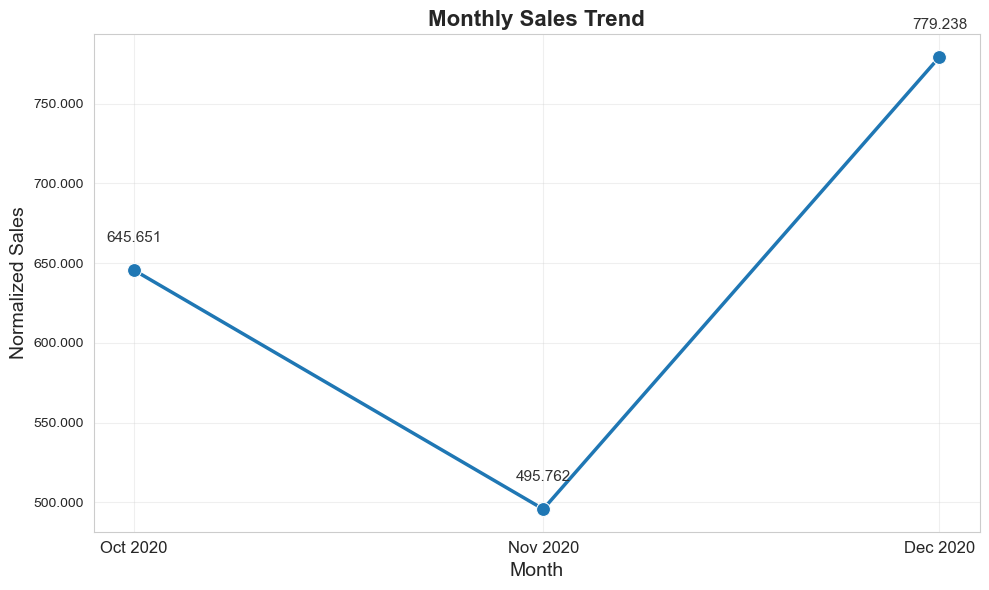

Interpretation:
The monthly trend chart shows normalized sales values for October, November, and December 2020. 
Values are shown directly on the line plot and the y-axis is formatted for the normalized scale.


In [45]:
# Monthly sales trend visualization
monthly_sales = monthly_summary['Sales']

plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

monthly_sales.index = monthly_sales.index.to_period('M')

ax = sns.lineplot(
    x=monthly_sales.index.to_timestamp(),
    y=monthly_sales.values,
    marker='o',
    linewidth=2.5,
    markersize=10,
    color='#1f77b4'
)

ax.set_title('Monthly Sales Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=14)
ax.set_ylabel('Normalized Sales', fontsize=14)
ax.set_xticks(monthly_sales.index.to_timestamp())
ax.set_xticklabels(monthly_sales.index.strftime('%b %Y'), fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.grid(True, alpha=0.3)

for x_val, y_val in zip(monthly_sales.index.to_timestamp(), monthly_sales.values):
    ax.text(
        x_val,
        y_val + monthly_sales.max() * 0.02,
        f'{y_val:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        color='#333333'
    )

plt.tight_layout()
plt.show()

print("Interpretation:")
print("The monthly trend chart shows normalized sales values for October, November, and December 2020. \nValues are shown directly on the line plot and the y-axis is formatted for the normalized scale.")

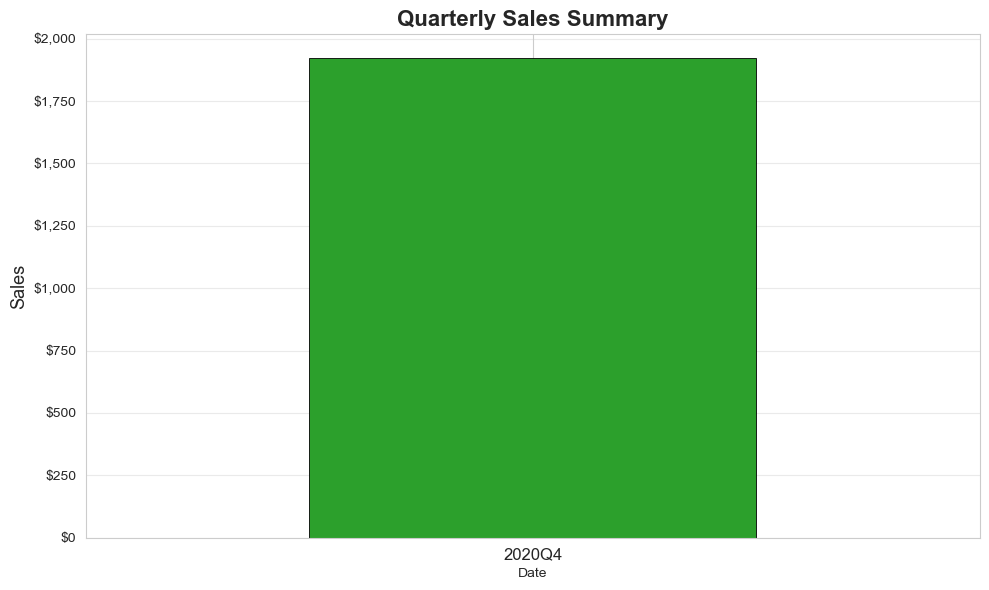

Interpretation:
Quarter 2020Q4 total sales: $1,921.


In [46]:
# Quarterly sales plot
qs = quarterly_summary['Sales']
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

palette = sns.color_palette('viridis', n_colors=max(1, len(qs)))
colors = [ '#2ca02c' if v == qs.max() else '#d62728' if v == qs.min() else palette[i] for i, v in enumerate(qs) ]

qs.plot(kind='bar', color=colors, ax=ax, edgecolor='k', linewidth=0.6)

labels = pd.to_datetime(qs.index).to_period('Q').astype(str)
ax.set_xticklabels(labels, rotation=0, fontsize=12)

ax.set_title('Quarterly Sales Summary', fontsize=16, fontweight='bold')
ax.set_ylabel('Sales', fontsize=13)

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if abs(x) >= 1e6 else f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.4)

# Annotate bars with value and percentage of total
total = qs.sum()
for i, (idx, v) in enumerate(qs.items()):
    ax.annotate(f'${v:,.0f}', (i, v), ha='center', va='bottom', fontsize=11, xytext=(0, 6), textcoords='offset points')
    if total > 0 and len(qs) > 1:
        pct = v / total * 100
        ax.annotate(f'{pct:.1f}%', (i, v), ha='center', va='top', fontsize=10, color='white',
                    xytext=(0, -8), textcoords='offset points', bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))

plt.tight_layout()
plt.show()

print("Interpretation:")
if len(qs) == 1:
    print(f"Quarter {labels[0]} total sales: ${qs.iloc[0]:,.0f}.")
else:
    print(f"Highest quarter: {pd.to_datetime(qs.idxmax()).to_period('Q')} (${qs.max():,.0f}). Lowest quarter: {pd.to_datetime(qs.idxmin()).to_period('Q')} (${qs.min():,.0f}).")

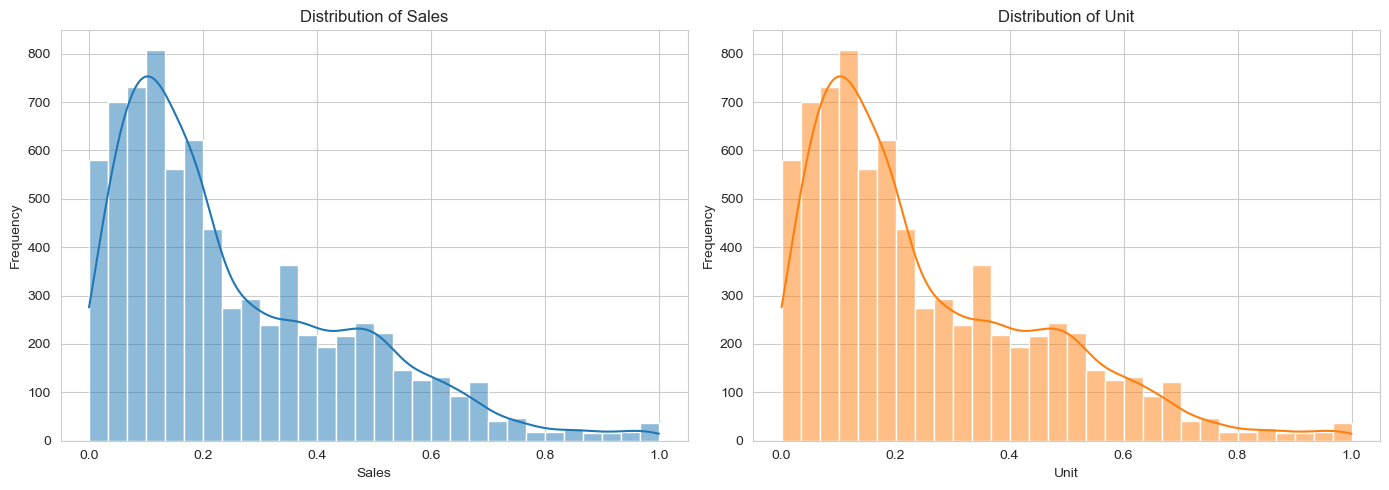

Sales: skewness=1.085 → positively skewed (right-skewed); concentrated around median ≈ 0.
Unit : skewness=1.085 → positively skewed (right-skewed); concentrated around median ≈ 0.


In [47]:
# Distribution plots for Sales and Unit with KDE and brief interpretation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['Sales'], kde=True, bins=30, color='C0', ax=ax1)
ax1.set_title('Distribution of Sales')
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')

sns.histplot(data['Unit'], kde=True, bins=30, color='C1', ax=ax2)
ax2.set_title('Distribution of Unit')
ax2.set_xlabel('Unit')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Compute skewness and give concise interpretation
sales_skew = stats.skew(data['Sales'])
unit_skew = stats.skew(data['Unit'])
sales_median = data['Sales'].median()
unit_median = data['Unit'].median()

def interpret_skew(skew):
    if skew > 0.2:
        return 'positively skewed (right-skewed)'
    if skew < -0.2:
        return 'negatively skewed (left-skewed)'
    return 'approximately symmetric'

print(f"Sales: skewness={sales_skew:.3f} → {interpret_skew(sales_skew)}; concentrated around median ≈ {sales_median:.0f}.")
print(f"Unit : skewness={unit_skew:.3f} → {interpret_skew(unit_skew)}; concentrated around median ≈ {unit_median:.0f}.")

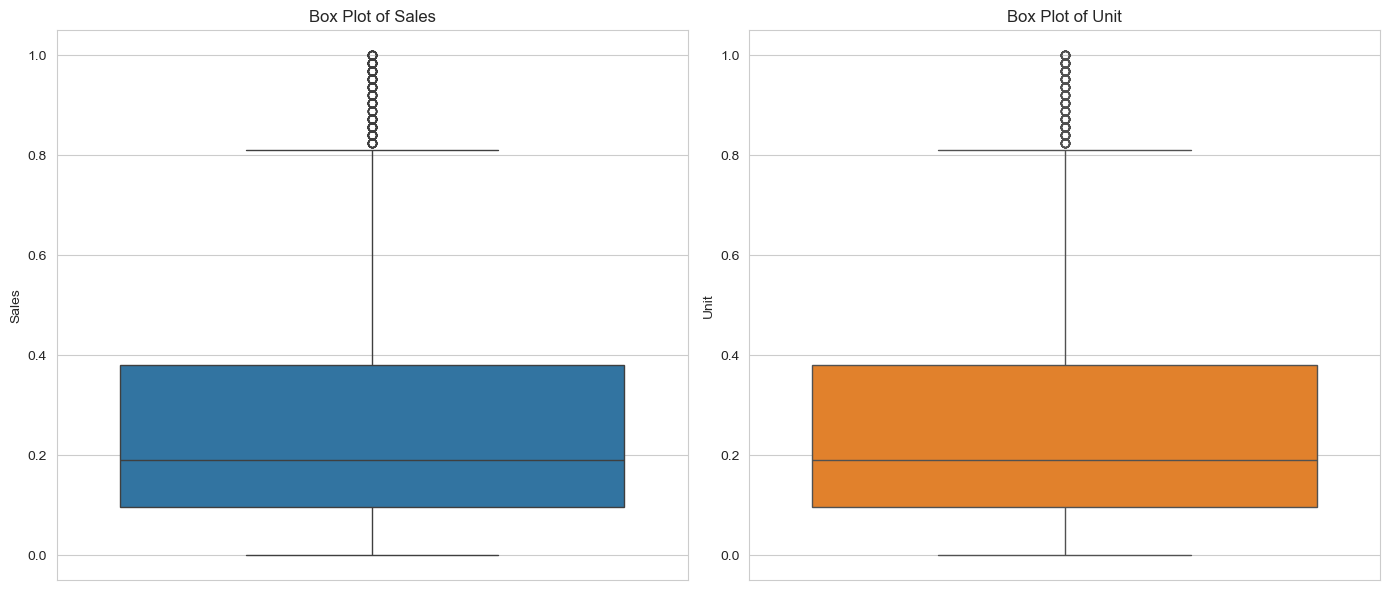

Sales — median: 0; IQR: 0; outliers: 123 (preview: [0.9682539682539683, 0.9523809523809523, 0.8571428571428571, 0.9047619047619048, 0.9841269841269841, 0.9365079365079365, 0.8253968253968254, 0.9206349206349206, 0.8412698412698413, 1.0])
Unit  — median: 0; IQR: 0; outliers: 123 (preview: [0.9682539682539683, 0.9523809523809523, 0.8571428571428571, 0.9047619047619048, 0.9841269841269841, 0.9365079365079365, 0.8253968253968254, 0.9206349206349206, 0.8412698412698413, 1.0])

Interpretation:
- Median: Sales ≈ 0, Unit ≈ 0.
- Spread: IQR (Sales) = 0, IQR (Unit) = 0, indicating the central 50% range.
- Outliers: Sales (123 values) and Unit (123 values) detected by IQR rule; preview shown above.
- Overall distribution: Sales skewness = 1.085 → right-skewed; Unit skewness = 1.085 → right-skewed.


In [48]:
# Create box plots for Sales and Unit and provide concise stats + outlier summary.
fig2, (ax_sales, ax_unit) = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=data['Sales'], ax=ax_sales, color='C0')
ax_sales.set_title('Box Plot of Sales')
sns.boxplot(y=data['Unit'], ax=ax_unit, color='C1')
ax_unit.set_title('Box Plot of Unit')
plt.tight_layout()
plt.show()
# IQR-based outlier detection and concise interpretation
def iqr_summary(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out = s[(s < lower) | (s > upper)]
    return {
        'median': s.median(),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': out.size,
        'outliers_preview': out.unique()[:10].tolist()
    }
sales_summary = iqr_summary(data['Sales'])
unit_summary = iqr_summary(data['Unit'])
print(f"Sales — median: {sales_summary['median']:.0f}; IQR: {sales_summary['iqr']:.0f}; outliers: {sales_summary['n_outliers']} (preview: {sales_summary['outliers_preview']})")
print(f"Unit  — median: {unit_summary['median']:.0f}; IQR: {unit_summary['iqr']:.0f}; outliers: {unit_summary['n_outliers']} (preview: {unit_summary['outliers_preview']})")
print("\nInterpretation:")
print(f"- Median: Sales ≈ {sales_summary['median']:.0f}, Unit ≈ {unit_summary['median']:.0f}.")
print(f"- Spread: IQR (Sales) = {sales_summary['iqr']:.0f}, IQR (Unit) = {unit_summary['iqr']:.0f}, indicating the central 50% range.")
print(f"- Outliers: Sales ({sales_summary['n_outliers']} values) and Unit ({unit_summary['n_outliers']} values) detected by IQR rule; preview shown above.")
print(f"- Overall distribution: Sales skewness = {sales_skew:.3f} → {'right-skewed' if sales_skew>0.2 else 'left-skewed' if sales_skew<-0.2 else 'approximately symmetric'}; Unit skewness = {unit_skew:.3f} → {'right-skewed' if unit_skew>0.2 else 'left-skewed' if unit_skew<-0.2 else 'approximately symmetric'}.")